In [35]:
!pip install adjustText
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import timedelta
from adjustText import adjust_text
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

sns.set_style("whitegrid")

comment_emotions = ["anger", "disgust", "fear", "joy", "neutral", "sadness", "surprise"]
post_emotions = ["post_anger", "post_disgust", "post_fear", "post_joy",
                 "post_neutral", "post_sadness", "post_surprise"]

In [36]:
def load_release_dates(csv_path="release_dates.csv"):
    df = pd.read_csv(csv_path)
    KEY_FIX = {
        "stardewvalley": "stardew",
        # 确保这里包含所有需要修正的key，例如：
        "stardew valley": "stardew",
        "counter-strike: global offensive": "csgo" # 举例
    }

    # 1. 创建小写的基础 key
    df["game_key"] = df["game"].str.lower()

    # 2. 应用修正
    # 这将把 KEY_FIX 中的键替换为对应的值
    df["game_key"] = df["game_key"].replace(KEY_FIX)

    # ... (函数的其余部分保持不变)
    df["release_date"] = pd.to_datetime(df["release_date"]).dt.date
    return df


def load_reddit_window(data_path='.', start_day=-30, end_day=-1, label="pre"):
    comment_files = glob.glob(os.path.join(data_path, '*_comments_with_emotion.csv'))
    summary_rows = []

    for cfile in comment_files:
        game_raw = os.path.basename(cfile).replace('_comments_with_emotion.csv', '')
        game_key = game_raw.lower()

        # ----- comments -----
        cdf = pd.read_csv(cfile)
        cdf = cdf.dropna(subset=["relday", "comment_sentiment_score"])
        cdf["relday_floor"] = cdf["relday"].astype(int)

        sub_c = cdf[(cdf["relday_floor"] >= start_day) & (cdf["relday_floor"] <= end_day)]
        if len(sub_c) == 0:
            continue

        comment_means = sub_c[comment_emotions].mean().to_dict()
        comment_means = {f"{label}_mean_{k}": v for k, v in comment_means.items()}

        row = {
            "game": game_raw,
            "game_key": game_key,
            "genre": sub_c["genre"].iloc[0] if "genre" in sub_c.columns else "Unknown",
            f"{label}_comment_sentiment": sub_c["comment_sentiment_score"].mean(),
            f"{label}_comment_volume": len(sub_c),
        }
        row.update(comment_means)

        # ----- posts -----
        pfile = os.path.join(data_path, f"{game_raw}_posts_with_emotion.csv")
        if os.path.exists(pfile):
            pdf = pd.read_csv(pfile)
            pdf = pdf.dropna(subset=["relday", "post_sentiment_score"])
            pdf["relday_floor"] = pdf["relday"].astype(int)

            sub_p = pdf[(pdf["relday_floor"] >= start_day) & (pdf["relday_floor"] <= end_day)]
            if len(sub_p) > 0:
                row[f"{label}_post_sentiment"] = sub_p["post_sentiment_score"].mean()
                row[f"{label}_post_volume"] = len(sub_p)

                post_means = sub_p[post_emotions].mean().to_dict()
                post_means = {
                    f"{label}_mean_post_{k.replace('post_', '')}": v
                    for k, v in post_means.items()
                }
                row.update(post_means)

        summary_rows.append(row)

    return pd.DataFrame(summary_rows)



def load_steamdb_data(data_path='.', release_df=None):
    KEY_FIX = {
        "stardewvalley": "stardew",
    }

    pattern = os.path.join(data_path, "**", "cleaned_*_data_*_full.csv")
    files = glob.glob(pattern, recursive=True)
    rows = []

    for f in files:
        base = os.path.basename(f)
        try:
            middle = base.replace("cleaned_", "")
            game_name = middle.split("_data_")[0]
            game_key = game_name.lower()
            game_key = KEY_FIX.get(game_key, game_key)
        except Exception:
            continue

        if game_key not in release_df["game_key"].values:
            continue

        release_date = release_df.loc[
            release_df["game_key"] == game_key, "release_date"
        ].iloc[0]

        df = pd.read_csv(f)
        df["datetime"] = pd.to_datetime(df["datetime"], errors='coerce').dt.date

        pre_start = release_date - timedelta(days=30)
        pre_end   = release_date - timedelta(days=1)
        pre_window = df[(df["datetime"] >= pre_start) & (df["datetime"] <= pre_end)]
        pre_peak = pre_window["players"].max() if not pre_window.empty else 0

        post_start = release_date
        post_end   = release_date + timedelta(days=90)
        post_window = df[(df["datetime"] >= post_start) & (df["datetime"] <= post_end)]
        post_peak = post_window["players"].max() if not post_window.empty else 0

        rows.append({
            "game_key": game_key,
            "pre_launch_peak_ccu": pre_peak,
            "post_launch_peak_ccu": post_peak,
        })

    return pd.DataFrame(rows)


def merge_datasets(reddit_df, steam_df):
    return pd.merge(reddit_df, steam_df, on="game_key", how="inner")


def aggregate_genre_emotions(df, label="pre"):
    emo_order = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
    cols = [f"{label}_mean_post_{e}" for e in emo_order if f"{label}_mean_post_{e}" in df.columns]
    if not cols:
        return pd.DataFrame()
    return df.groupby("genre")[cols].mean().reset_index()

def label_point(ax, x, y, text, color, y_offset_factor=0.05):
    offset_x = x * 0.03
    offset_y = max(abs(y) * y_offset_factor, 8)

    if abs(y) < 0.001:
        offset_y += np.random.uniform(-12, 12)

    ax.text(
        x + offset_x,
        y + offset_y,
        text,
        fontsize=10,
        color=color,
        weight="bold",
        ha="left",
        va="bottom"
    )

# ------------------------------
# 1. Emotion Distribution (Comments) — Heatmap
# ------------------------------

In [37]:
def plot_emotion_heatmap_pre_post(df_pre, df_post):
    emo_order = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]
    desired_order = ["Apex", "DeltaForce", "PUBG", "Palworld", "PlanetZoo", "Stardew"]

    rows = []
    index_labels = []

    for game in desired_order:
        # Pre
        sub_pre = df_pre[df_pre["game"] == game]
        if not sub_pre.empty:
            r = sub_pre.iloc[0]
            index_labels.append(f"{game} (Pre)")
            rows.append([r.get(f"pre_mean_{e}", np.nan) for e in emo_order])

        # Post
        sub_post = df_post[df_post["game"] == game]
        if not sub_post.empty:
            r = sub_post.iloc[0]
            index_labels.append(f"{game} (Post)")
            rows.append([r.get(f"post_mean_{e}", np.nan) for e in emo_order])

    if not rows:
        print("No data available for emotion heatmap.")
        return

    data = pd.DataFrame(rows, index=index_labels, columns=emo_order)

    cols = [c for c in data.columns if c != "neutral"] + ["neutral"]
    data = data[cols]

    plt.figure(figsize=(9, 6))
    ax = sns.heatmap(
        data,
        annot=True,
        cmap="OrRd",
        fmt=".02f",
        cbar_kws={"label": "Mean Emotion Score"},
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.title("Emotion Distribution (Comments) — Pre vs Post")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.savefig("Emotion Distribution (Comments) — Pre vs Post.png", dpi=300)
    plt.show()

# ------------------------------
# 2. Sentiment vs Comment Volume vs CCU — Bubble Plot
# ------------------------------

In [38]:
def plot_bubble_pre_post(df_pre, df_post):
    fig, ax = plt.subplots(figsize=(15, 8))

    all_vol = np.concatenate([
        df_pre["pre_comment_volume"].values,
        df_post["post_comment_volume"].values
    ])
    norm = plt.Normalize(all_vol.min(), all_vol.max())
    cmap = plt.cm.viridis

    texts = []

    for g in df_pre["game"].unique():
        if g not in df_post["game"].unique():
            continue

        r_pre = df_pre[df_pre["game"] == g].iloc[0]
        r_post = df_post[df_post["game"] == g].iloc[0]

        x_pre  = r_pre["pre_comment_sentiment"]
        x_post = r_post["post_comment_sentiment"]
        y_pre  = r_pre["pre_launch_peak_ccu"]
        y_post = r_post["post_launch_peak_ccu"]

        radius_pre  = np.sqrt(r_pre["pre_comment_volume"]) * 40
        radius_post = np.sqrt(r_post["post_comment_volume"]) * 40

        ax.scatter(x_pre, y_pre, s=radius_pre,  color=cmap(norm(r_pre["pre_comment_volume"])),
                   alpha=0.75, edgecolors="black", linewidth=0.7)
        texts.append(ax.text(x_pre, y_pre, f"{g} (Pre)", fontsize=11))

        ax.scatter(x_post, y_post, s=radius_post, color=cmap(norm(r_post["post_comment_volume"])),
                   alpha=0.75, edgecolors="black", linewidth=0.7)
        texts.append(ax.text(x_post, y_post, f"{g} (Post)", fontsize=11))

        ax.plot([x_pre, x_post], [y_pre, y_post], "--", color="gray", alpha=0.7)

    adjust_text(texts)

    ax.set_xlabel("Comment Sentiment Score")
    ax.set_ylabel("Launch Peak CCU")
    ax.set_title("Pre vs Post — Sentiment × Volume × Launch Peak CCU")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax).set_label("Comment Volume")

    fig.tight_layout()
    fig.savefig("Comment Sentiment vs Comment Volume vs CCU — Bubble Plot.png", dpi=300)
    plt.show()


def plot_bubble_stats(df_pre, df_post):

    rows = []

    for g in df_pre["game"].unique():
        if g not in df_post["game"].unique():
            continue

        r_pre = df_pre[df_pre["game"] == g].iloc[0]
        r_post = df_post[df_post["game"] == g].iloc[0]

        rows.append([
            g,
            round(r_pre["pre_comment_sentiment"], 3),
            round(r_post["post_comment_sentiment"], 3),
            round(r_post["post_comment_sentiment"] - r_pre["pre_comment_sentiment"], 3),
            int(r_pre["pre_comment_volume"]),
            int(r_post["post_comment_volume"]),
            int(r_post["post_comment_volume"] - r_pre["pre_comment_volume"]),
            int(r_pre["pre_launch_peak_ccu"]),
            int(r_post["post_launch_peak_ccu"]),
            int(r_post["post_launch_peak_ccu"] - r_pre["pre_launch_peak_ccu"])
        ])

    df = pd.DataFrame(rows, columns=[
        "Game",
        "Pre Sent", "Post Sent", "Δ Sent",
        "Pre Vol", "Post Vol", "Δ Vol",
        "Pre CCU", "Post CCU", "Δ CCU"
    ])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.axis("off")

    plt.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    plt.title("Bubble Plot — Stats Table")
    fig.savefig("Bubble Plot — Stats Table.png", dpi=300)
    plt.show()


# ------------------------------
# 3. Sentiment Distribution Between Genres - Radar Chart
# ------------------------------


In [39]:
def plot_radar_chart_pre_post(df_pre, df_post):
    emo = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

    pre_g = aggregate_genre_emotions(df_pre, "pre")
    post_g = aggregate_genre_emotions(df_post, "post")

    genres = sorted(set(pre_g["genre"]).intersection(post_g["genre"]))
    if not genres:
        print("No genres.")
        return

    all_vals = []
    for e in emo:
        all_vals += list(pre_g[f"pre_mean_post_{e}"])
        all_vals += list(post_g[f"post_mean_post_{e}"])
    rmax = max(all_vals) * 1.15

    angles = np.linspace(0, 2*np.pi, len(emo), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(16, 6))

    ax1 = plt.subplot(1,2,1, polar=True)
    for g in genres:
        row = pre_g[pre_g.genre==g].iloc[0]
        vals = [row[f"pre_mean_post_{e}"] for e in emo]
        vals += vals[:1]
        ax1.plot(angles, vals, linewidth=2, label=g)
        ax1.fill(angles, vals, alpha=0.15)
    ax1.set_ylim(0, rmax)
    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(emo)
    ax1.set_title("Genre-level Sentiment (Posts) — PRE")
    ax1.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))

    ax2 = plt.subplot(1,2,2, polar=True)
    for g in genres:
        row = post_g[post_g.genre==g].iloc[0]
        vals = [row[f"post_mean_post_{e}"] for e in emo]
        vals += vals[:1]
        ax2.plot(angles, vals, linewidth=2, label=g)
        ax2.fill(angles, vals, alpha=0.15)
    ax2.set_ylim(0, rmax)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(emo)
    ax2.set_title("Genre-level Sentiment (Posts) — POST")
    ax2.legend(loc="upper right", bbox_to_anchor=(1.2,1.1))

    plt.tight_layout()
    plt.savefig("Genre-level Sentiment (Posts) - Radar.png", dpi=300)
    plt.show()


def plot_radar_stats_table(df_pre, df_post):
    emo = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

    pre_g = aggregate_genre_emotions(df_pre, "pre")
    post_g = aggregate_genre_emotions(df_post, "post")

    genres = sorted(set(pre_g["genre"]).intersection(post_g["genre"]))
    if not genres:
        print("No genre overlap for stats table.")
        return

    rows = []
    for g in genres:
        pre_row = pre_g[pre_g.genre == g].iloc[0]
        post_row = post_g[post_g.genre == g].iloc[0]

        # first row: genre label appears
        first = True
        for e in emo:
            pre_val = pre_row[f"pre_mean_post_{e}"]
            post_val = post_row[f"post_mean_post_{e}"]
            delta_val = post_val - pre_val

            rows.append([
                g if first else "",             # Only first line shows Genre
                e,
                round(pre_val, 4),
                round(post_val, 4),
                round(delta_val, 4)
            ])
            first = False

    df_stats = pd.DataFrame(rows, columns=[
        "Genre", "Emotion", "PRE_mean", "POST_mean", "Δ POST-PRE"
    ])

    fig, ax = plt.subplots(figsize=(9, len(df_stats) * 0.4))
    ax.axis("off")

    table = plt.table(
        cellText=df_stats.values,
        colLabels=df_stats.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)

    plt.title("Radar Plot — Stats Table (PRE vs POST Genre-level Emotions)", fontsize=14)

    fig.savefig("Radar Plot — Stats Table (Merged Genre).png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ------------------------------
# 4. Sentiment Bar Gradient
# ------------------------------

In [40]:
def plot_sentiment_bar_pre_post(df_pre, df_post):
    pre_cols = ["game", "game_key", "pre_comment_sentiment"]
    post_cols = ["game", "game_key", "post_comment_sentiment"]

    pre_small = df_pre[pre_cols].rename(columns={"game": "game_pre"})
    post_small = df_post[post_cols].rename(columns={"game": "game_post"})

    merged = pd.merge(pre_small, post_small, on="game_key", how="inner")

    if merged.empty:
        print("No overlapping games for sentiment bar chart.")
        return

    merged["game"] = merged["game_pre"]

    desired_order = ["Apex", "DeltaForce", "PUBG", "Palworld", "PlanetZoo", "Stardew"]
    order = [g for g in desired_order if g in merged["game"].values]
    merged = merged.set_index("game").loc[order].reset_index()

    x = np.arange(len(merged))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5.5))

    bars_pre = ax.bar(
        x - width / 2, merged["pre_comment_sentiment"],
        width=width, label="Pre-launch",
        color="#3d9de2", edgecolor="black", linewidth=0.5
    )
    bars_post = ax.bar(
        x + width / 2, merged["post_comment_sentiment"],
        width=width, label="Post-launch",
        color="#f5913a", edgecolor="black", linewidth=0.5
    )

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            if height >= 0:
                # positive values → above bar
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.005,
                    f"{height:.3f}",
                    ha="center", va="bottom", fontsize=9
                )
            else:
                # negative values → below bar
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height - 0.005,
                    f"{height:.3f}",
                    ha="center", va="top", fontsize=9
                )

    add_labels(bars_pre)
    add_labels(bars_post)

    ax.axhline(0, color="black", linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(merged["game"], rotation=20, ha="right")

    ax.set_ylabel("Comment Sentiment Score")
    ax.set_title("Game-level Sentiment — Pre vs Post")
    ax.legend()

    plt.tight_layout()
    plt.savefig("Sentiment Bar — Pre vs Post (Labeled).png", dpi=300)
    plt.show()


# ------------------------------
# 5. Volume vs CCU (log + genre)
# ------------------------------


In [41]:
def plot_volume_vs_ccu_pre_post(df_pre, df_post):
    genres = sorted(set(df_pre["genre"]).intersection(df_post["genre"]))

    fig, axes = plt.subplots(1, len(genres), figsize=(14, 6), sharey=True)

    if len(genres) == 1:
        axes = [axes]

    for ax, genre in zip(axes, genres):
        sub_pre = df_pre[df_pre["genre"] == genre]
        sub_post = df_post[df_post["genre"] == genre]

        ax.scatter(
            sub_pre["pre_comment_volume"],
            sub_pre["pre_launch_peak_ccu"],
            label="Pre-launch",
            s=70,
            edgecolors="black"
        )

        ax.scatter(
            sub_post["post_comment_volume"],
            sub_post["post_launch_peak_ccu"],
            label="Post-launch",
            s=70,
            edgecolors="black"
        )

        # ------- Handle Simulation overlapping labels -------
        overlapped_games = ["Palworld", "PlanetZoo"]
        smaller_game = bigger_game = None

        if genre == "Simulation":
            tmp = sub_pre[sub_pre["game"].isin(overlapped_games)]
            if len(tmp) == 2:
                vols = tmp.set_index("game")["pre_comment_volume"]
                smaller_game = vols.idxmin()
                bigger_game = vols.idxmax()

        # ----------- Pre-launch labels -----------
        for _, row in sub_pre.iterrows():
            x = row["pre_comment_volume"]
            y = row["pre_launch_peak_ccu"]
            gname = row["game"]

            if genre == "Simulation" and gname in overlapped_games and smaller_game:
                if gname == smaller_game:
                    ax.annotate(
                        gname, (x, y),
                        xytext=(0, 8),
                        textcoords="offset points",
                        ha="center", va="bottom",
                        fontsize=10, color="#1f77b4"
                    )
                elif gname == bigger_game:
                    ax.annotate(
                        gname, (x, y),
                        xytext=(0, -10),
                        textcoords="offset points",
                        ha="center", va="top",
                        fontsize=10, color="#1f77b4"
                    )
            else:
                label_point(ax, x, y, gname, "#1f77b4")

        # ----------- Post-launch labels -----------
        for _, row in sub_post.iterrows():
            label_point(
                ax,
                row["post_comment_volume"],
                row["post_launch_peak_ccu"],
                row["game"],
                "#ff7f0e"
            )

        # ------- Regression (pre) -------
        if len(sub_pre) >= 2:
            X_pre = np.log10(sub_pre["pre_comment_volume"].values).reshape(-1, 1)
            y_pre = sub_pre["pre_launch_peak_ccu"].values
            model_pre = LinearRegression().fit(X_pre, y_pre)

            xs = np.linspace(X_pre.min(), X_pre.max(), 50)
            ax.plot(
                10**xs,
                model_pre.predict(xs.reshape(-1, 1)),
                linestyle='--',
                color='blue',
                alpha=0.7
            )

        # ------- Regression (post) -------
        if len(sub_post) >= 2:
            X_post = np.log10(sub_post["post_comment_volume"].values).reshape(-1, 1)
            y_post = sub_post["post_launch_peak_ccu"].values
            model_post = LinearRegression().fit(X_post, y_post)

            xs = np.linspace(X_post.min(), X_post.max(), 50)
            ax.plot(
                10**xs,
                model_post.predict(xs.reshape(-1, 1)),
                linestyle='--',
                color='orange',
                alpha=0.7
            )

        ax.set_xscale("log")
        ax.set_title(genre)
        ax.set_xlabel("Comment Volume (log scale)")

    axes[0].set_ylabel("Launch Peak CCU")
    fig.suptitle("Comment Volume vs Launch Peak CCU — Regression (Labeled)", fontsize=18)
    fig.legend(loc="upper right")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig("Regression — Comment Volume vs Launch Peak CCU (Labeled).png", dpi=300)
    plt.show()




def plot_regression_stats_table(df_pre, df_post):
    genres = sorted(set(df_pre["genre"]).intersection(df_post["genre"]))
    rows = []

    for genre in genres:
        sub_pre = df_pre[df_pre["genre"] == genre]
        sub_post = df_post[df_post["genre"] == genre]

        # Pre
        if len(sub_pre) >= 2:
            X_pre = np.log10(sub_pre["pre_comment_volume"].values).reshape(-1, 1)
            y_pre = sub_pre["pre_launch_peak_ccu"].values
            model_pre = LinearRegression().fit(X_pre, y_pre)

            slope_pre = model_pre.coef_[0]
            intercept_pre = model_pre.intercept_
            r2_pre = r2_score(y_pre, model_pre.predict(X_pre))
        else:
            slope_pre = intercept_pre = r2_pre = np.nan

        # Post
        if len(sub_post) >= 2:
            X_post = np.log10(sub_post["post_comment_volume"].values).reshape(-1, 1)
            y_post = sub_post["post_launch_peak_ccu"].values
            model_post = LinearRegression().fit(X_post, y_post)

            slope_post = model_post.coef_[0]
            intercept_post = model_post.intercept_
            r2_post = r2_score(y_post, model_post.predict(X_post))
        else:
            slope_post = intercept_post = r2_post = np.nan

        delta_slope = slope_post - slope_pre

        rows.append([
            genre,
            f"y = {slope_pre:.2e}\n+ {intercept_pre:.2e}",
            f"y = {slope_post:.2e}\n+ {intercept_post:.2e}",
            f"{delta_slope:.2e}",
            round(r2_pre, 4),
            round(r2_post, 4)
        ])


    df_stats = pd.DataFrame(rows, columns=[
        "Genre", "Pre Equation", "Post Equation",
        "Δ Slope (Post-Pre)", "R2_Pre", "R2_Post"
    ])

    fig, ax = plt.subplots(figsize=(12, 2 + len(df_stats) * 0.5))
    ax.axis("off")

    table = plt.table(
        cellText=df_stats.values,
        colLabels=df_stats.columns,
        cellLoc="center",
        loc="center",
        bbox=[0, 0, 1, 1]
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.auto_set_column_width(col=list(range(len(df_stats.columns))))

    plt.title("Regression Model Comparison (Per Genre)", fontsize=16)
    fig.savefig("Regression_Model_Comparison_Table.png", dpi=300, bbox_inches="tight")
    plt.show()


# ------------------------------
# Main
# ------------------------------


/tmp/ipython-input-2982445193.py:31: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  cdf = pd.read_csv(cfile)
/tmp/ipython-input-2982445193.py:31: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  cdf = pd.read_csv(cfile)


Pre-launch games: ['Apex', 'Stardew', 'PUBG', 'Palworld', 'DeltaForce', 'PlanetZoo']
Post-launch games: ['Apex', 'Stardew', 'PUBG', 'Palworld', 'DeltaForce', 'PlanetZoo']


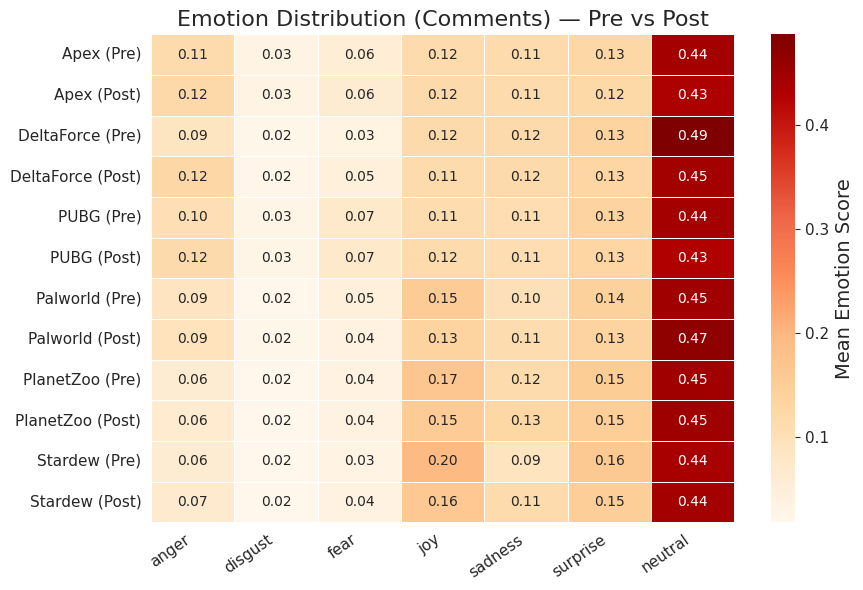

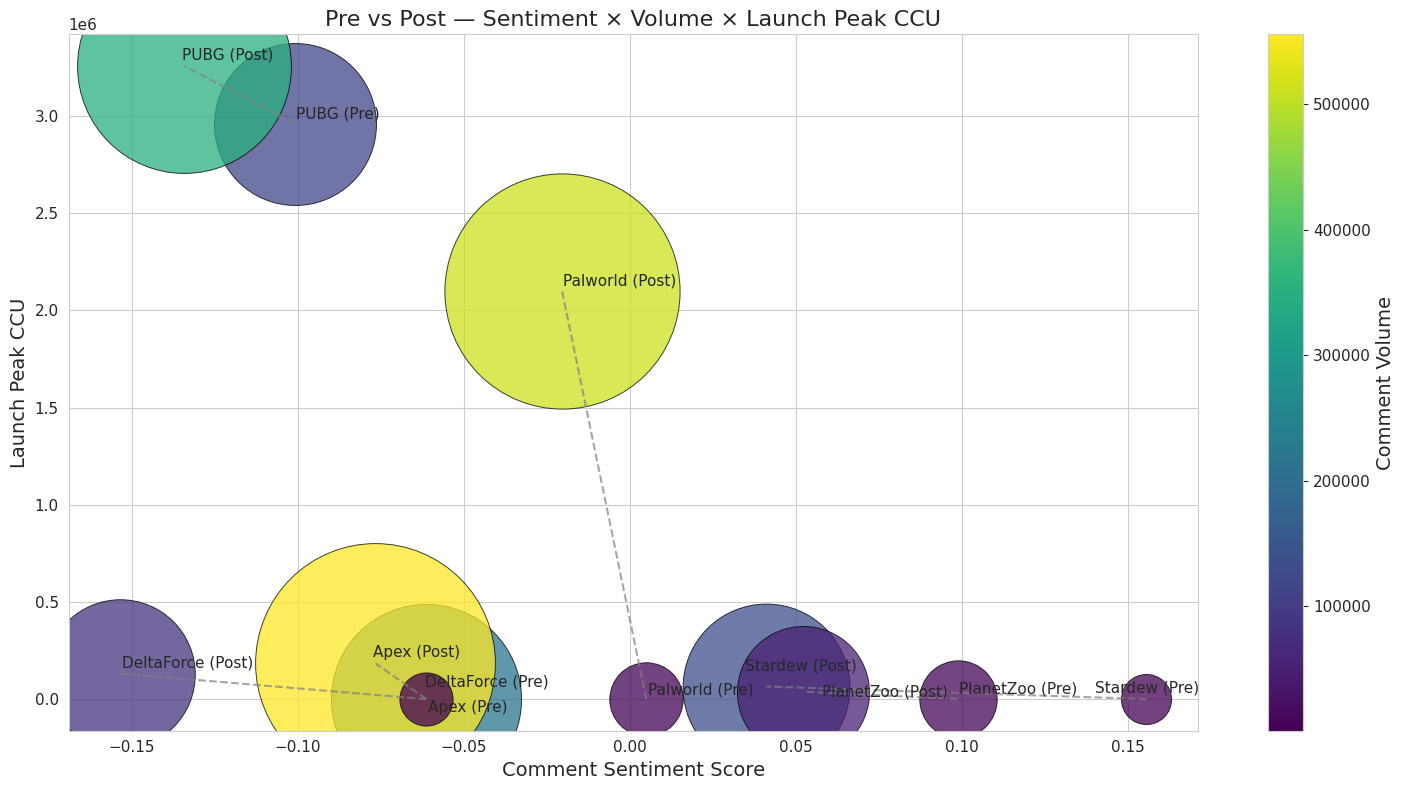

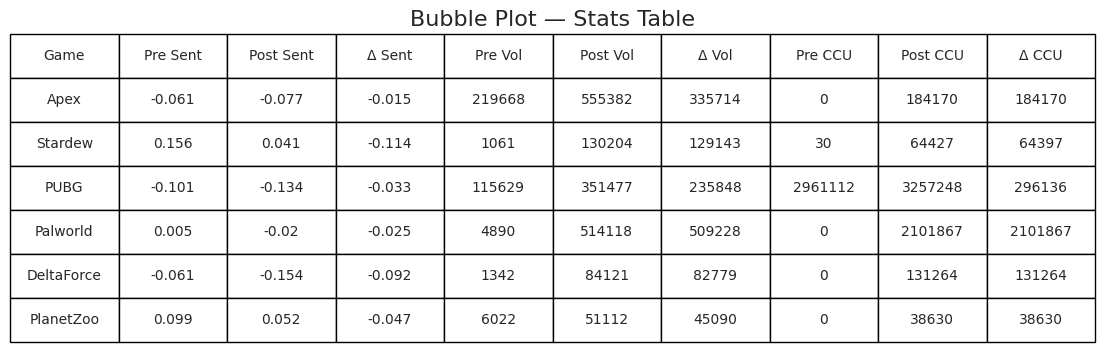

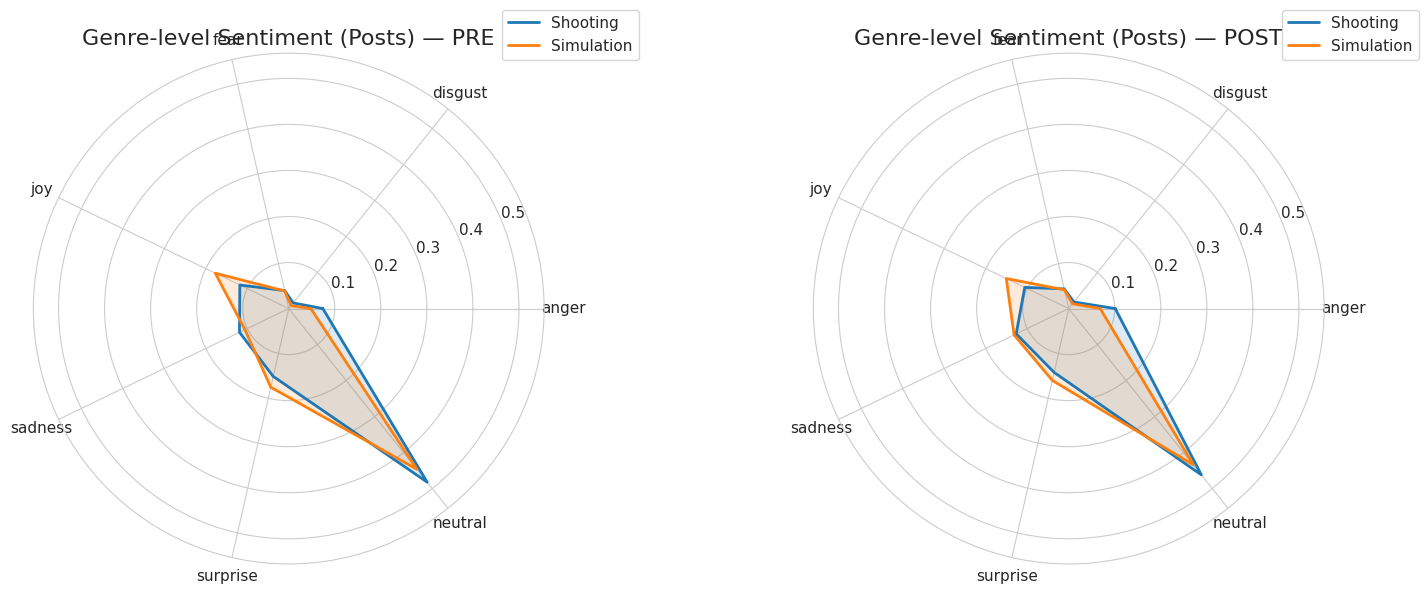

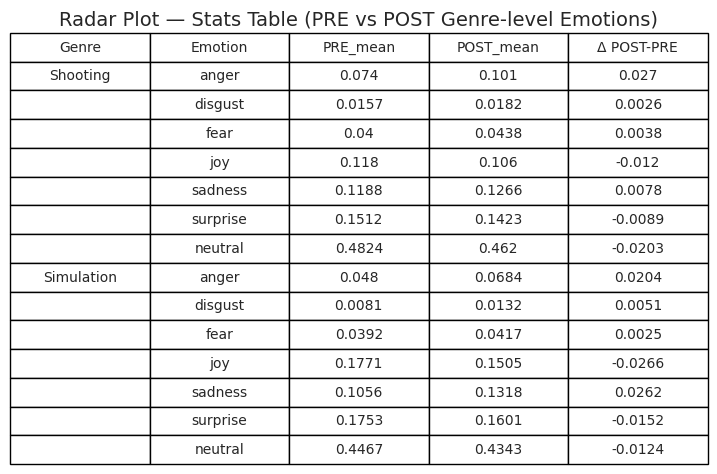

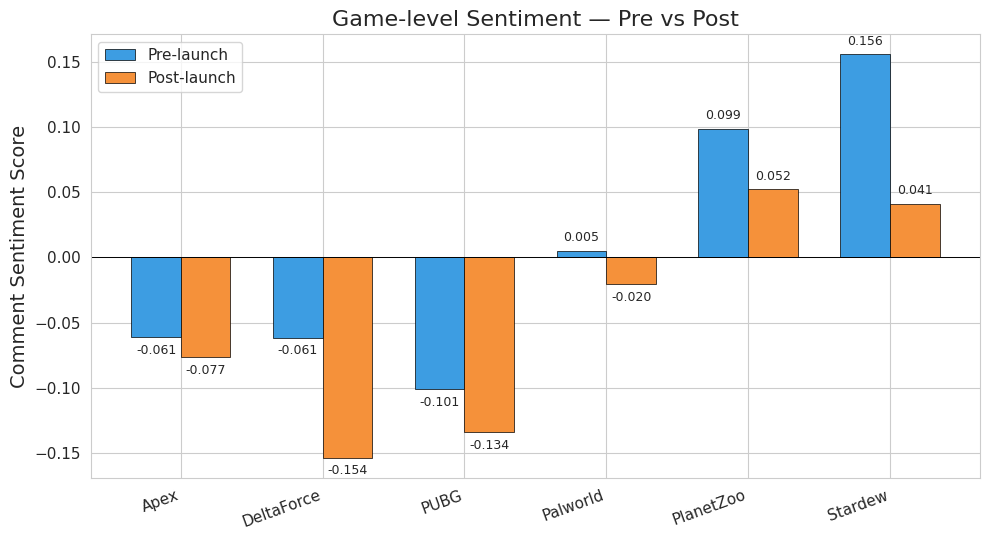

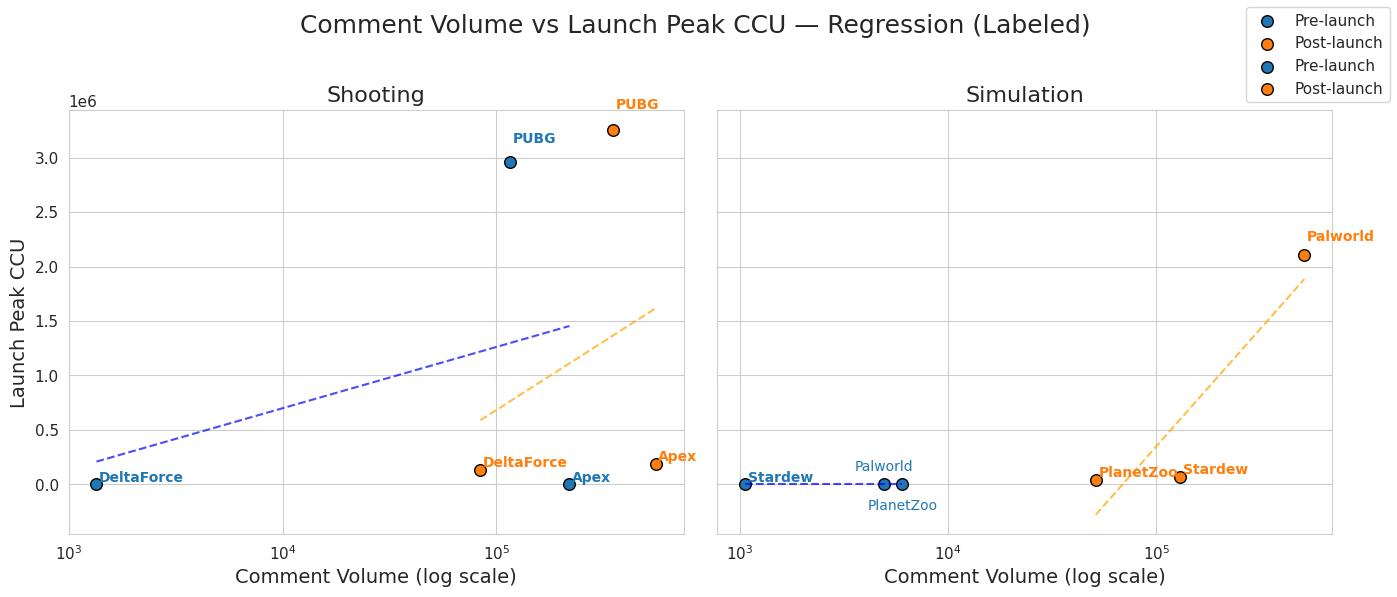

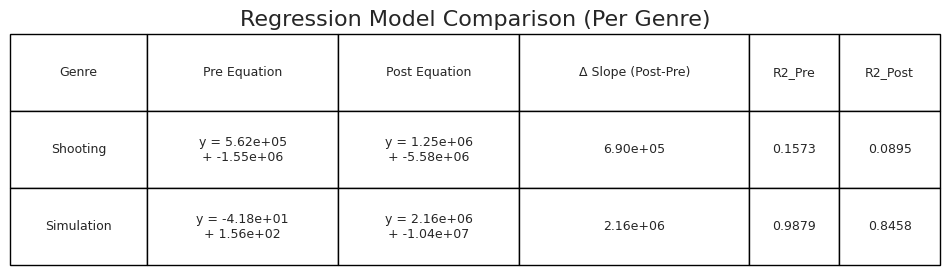


All Pre + Post visualizations generated.


In [42]:
def main():
    release_df = load_release_dates("release_dates.csv")
    reddit_pre = load_reddit_window(start_day=-30, end_day=-1, label="pre")
    reddit_post = load_reddit_window(start_day=0, end_day=90, label="post")
    steamdb_summary = load_steamdb_data(release_df=release_df)

    merged_pre = merge_datasets(reddit_pre, steamdb_summary)
    merged_post = merge_datasets(reddit_post, steamdb_summary)

    print("Pre-launch games:", merged_pre["game"].tolist())
    print("Post-launch games:", merged_post["game"].tolist())

    plot_emotion_heatmap_pre_post(merged_pre, merged_post)
    plot_bubble_pre_post(merged_pre, merged_post)
    plot_bubble_stats(merged_pre, merged_post)
    plot_radar_chart_pre_post(merged_pre, merged_post)
    plot_radar_stats_table(merged_pre, merged_post)
    plot_sentiment_bar_pre_post(merged_pre, merged_post)
    plot_volume_vs_ccu_pre_post(merged_pre, merged_post)
    plot_regression_stats_table(merged_pre, merged_post)


    print("\nAll Pre + Post visualizations generated.")

if __name__ == "__main__":
    main()